In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from utils import data

In [67]:
df = data.load_analysis_columns([
    "patient_id", "sequence_id", "collection_date", "datazone", "dz_simd_quintile",
    "who_voc", "window_idx", "wn_mid_date", "cluster_id", "vacc_dose_number"
])
df = df.to_pandas()
df["vacc_dose_number"] = df["vacc_dose_number"].fillna(0).astype(int)
df["who_voc"] = df["who_voc"].fillna("Pre-VOC/Unknown")

main_voc = {"Alpha", "Delta", "Omicron", "Pre-VOC/Unknown"}
df["voc"] = df["who_voc"].where(df["who_voc"].isin(main_voc), "recombinant")
_NON_SINGLETON_RE = r"\|C\d+$"
df["in_cluster"] = df["cluster_id"].str.contains(_NON_SINGLETON_RE).astype(bool)

gdf = data.load_datazone_info(["datazone", "dz_simd_quintile", "geometry", "dz_council_area", "dz_health_board", "dz_simd_rank"])
dzs = df.groupby("datazone").agg(
    simd_quintile=("dz_simd_quintile", "first"),
    prop_clustered=("in_cluster", "mean"),
    n_sequences=("sequence_id",      "count")
).reset_index()
gdf = gdf.reset_index().merge(dzs, on="datazone", how="left")

df = df.merge(gdf[["datazone", "dz_council_area", "dz_health_board"]], on="datazone", how="left")

In [68]:
dd = df.groupby("window_idx").agg(
    patient_ids=("patient_id", "nunique"),
    sequences=("sequence_id", "nunique")
)


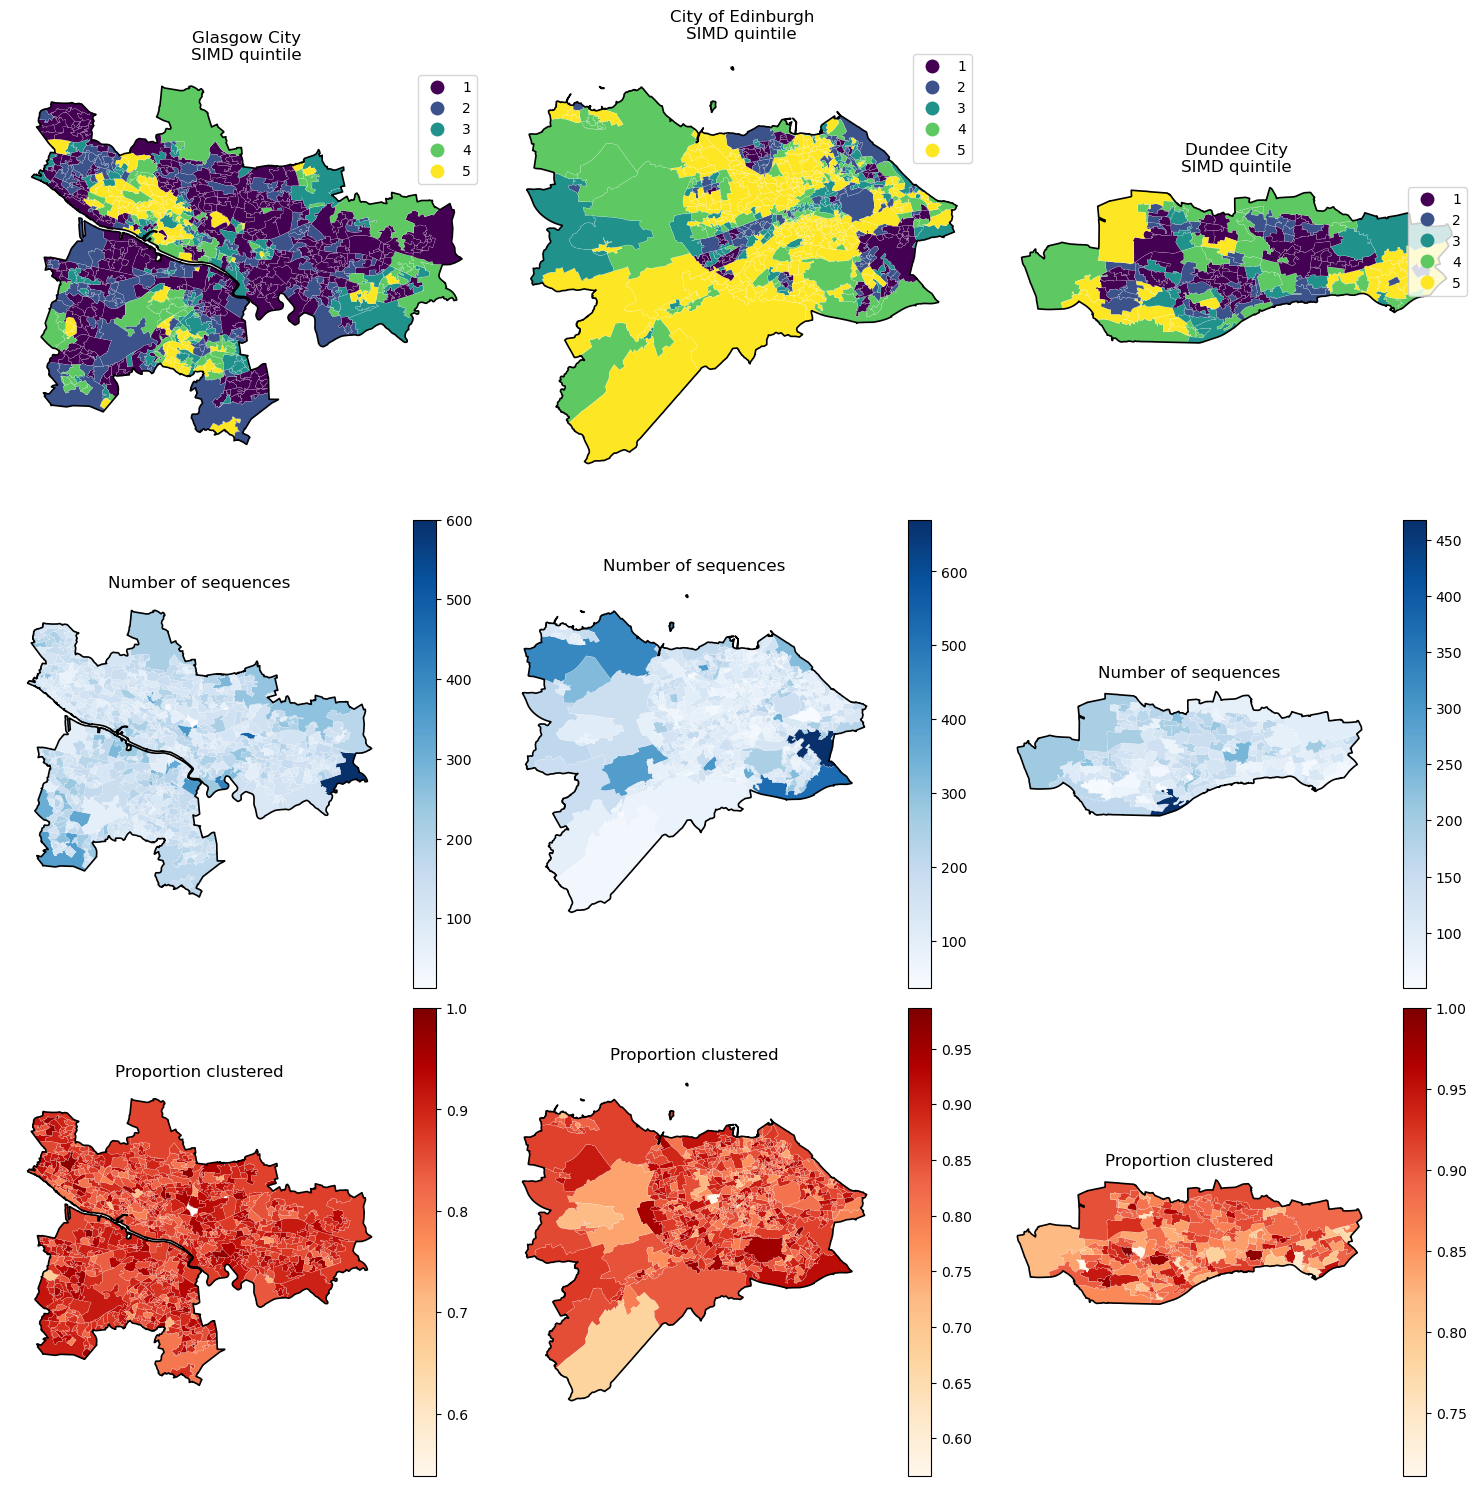

In [55]:
selected_areas = [
    "Glasgow City",
    "City of Edinburgh",
    "Dundee City"
]

simd_col = "dz_simd_quintile"
nseq_col = "n_sequences"
prop_col = "prop_clustered"
area_col = "dz_council_area"

dz_sel = gdf[gdf[area_col].isin(selected_areas)].copy()

dz_sel[simd_col] = dz_sel[simd_col].astype(int)
dz_sel[nseq_col] = dz_sel[nseq_col].astype(float)
dz_sel[prop_col] = dz_sel[prop_col].astype(float)

fig, axes = plt.subplots(
    3, len(selected_areas),
    figsize=(5 * len(selected_areas), 15)
)

if len(selected_areas) == 1:
    axes = axes.reshape(3, 1)

for j, area in enumerate(selected_areas):
    dz_area = dz_sel[dz_sel[area_col] == area].copy()
    council_boundary = dz_area.dissolve(by=area_col).boundary

    dz_area.plot(
        column=simd_col,
        categorical=True,
        cmap="viridis",
        legend=True,
        edgecolor="white",
        linewidth=0.1,
        ax=axes[0, j]
    )
    council_boundary.plot(ax=axes[0, j], color="black", linewidth=1.2)
    axes[0, j].set_title(f"{area}\nSIMD quintile")
    axes[0, j].set_axis_off()

    dz_area.plot(
        column=nseq_col,
        cmap="Blues",
        legend=True,
        edgecolor="white",
        linewidth=0.1,
        ax=axes[1, j]
    )
    council_boundary.plot(ax=axes[1, j], color="black", linewidth=1.2)
    axes[1, j].set_title("Number of sequences")
    axes[1, j].set_axis_off()

    dz_area.plot(
        column=prop_col,
        cmap="OrRd",
        legend=True,
        edgecolor="white",
        linewidth=0.1,
        ax=axes[2, j]
    )
    council_boundary.plot(ax=axes[2, j], color="black", linewidth=1.2)
    axes[2, j].set_title("Proportion clustered")
    axes[2, j].set_axis_off()

plt.tight_layout()
plt.show()

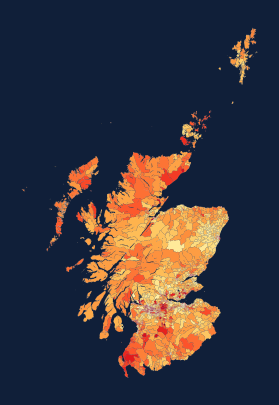

In [85]:
bg = (16/255, 31/255, 57/255)  # RGB 16, 31, 57
aspect_ratio = 16/9
height = 5
width = height * aspect_ratio

gdf_plot = gdf.to_crs("EPSG:27700")

fig, ax = plt.subplots(figsize=(width, height), facecolor=bg)
ax.set_facecolor(bg)

gdf_plot.plot(
    column="dz_simd_rank",
    cmap="YlOrRd_r",
    linewidth=0.08,
    edgecolor=(1, 1, 1, 0.35),
    missing_kwds={
        "color": "#9aa3ad",
        "edgecolor": (1, 1, 1, 0.35),
        "hatch": "///",
        "label": "Missing"
    },
    ax=ax
)

ax.set_axis_off()
plt.show()

fig.savefig("scottish_map.png", dpi=600, bbox_inches="tight")

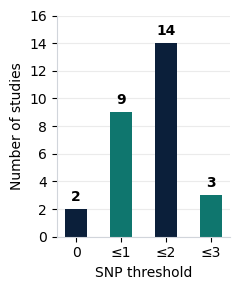

In [93]:

snp = pd.DataFrame({
    "SNP threshold": ["0", "﷿﷿﷿1", "﷿﷿﷿2", "﷿﷿﷿3"],
    "No. studies": [2, 9, 14, 3]
})

fig, ax = plt.subplots(figsize=(2.5, 3))  # 16:9 slide-friendly

bars = ax.bar(
    snp["SNP threshold"],
    snp["No. studies"],
    color=["#0B1F3A", "#0F766E", "#0B1F3A", "#0F766E"],
    width=0.5
)
# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.35,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# Styling

# ax.set_title(
#     "SNP Threshold used define 'relatedness'",
#     # fontsize=26,
#     fontweight="bold",
#     # pad=22,
#     color="#0B1F3A"
# )

ax.set_xlabel("SNP threshold")
ax.set_ylabel("Number of studies")
ax.set_ylim(0, 16)
ax.set_yticks(range(0, 17, 2))
ax.tick_params(axis="both",)
ax.grid(axis="y", linestyle="-", alpha=0.25)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D1D5DB")
ax.spines["bottom"].set_color("#D1D5DB")
plt.tight_layout()

svg_path = "snp_threshold_relatedness_vertical_figure.svg"
fig.savefig(svg_path, bbox_inches="tight", transparent=False)
plt.show()